## 1. Libraries



We begin by importing the Python libraries needed for the project.

- `yfinance` is used to download historical financial data from Yahoo Finance.
- `numpy` is used for numerical computations, in particular vector and matrix operations.

These tools will allow us to construct and analyze portfolios in the Markowitz framework.

In [5]:
import yfinance as yf
import numpy as np

## 2. Download historical price data

We select a set of assets:
- AAPL
- MSFT
- GOOG
- AMZN
- SPY

We then download their adjusted closing prices from Yahoo Finance, starting on 2020-01-01.

The adjusted close price is the relevant price series for return calculations, since it accounts for corporate actions such as stock splits and dividends.

At this stage, the data still consists of prices, not returns.

In [6]:
tickers = ["AAPL", "MSFT", "GOOG", "AMZN", "SPY"]
data = yf.download(tickers, start="2020-01-01", auto_adjust=True)["Close"]
print(data.head())

[*********************100%***********************]  5 of 5 completed

Ticker           AAPL       AMZN       GOOG        MSFT         SPY
Date                                                               
2020-01-02  72.400505  94.900497  67.811775  152.158386  296.888184
2020-01-03  71.696632  93.748497  67.478996  150.263763  294.640106
2020-01-06  72.267929  95.143997  69.142845  150.652161  295.764191
2020-01-07  71.928055  95.343002  69.099701  149.278519  294.932526
2020-01-08  73.085106  94.598503  69.644234  151.656296  296.504303


**Explanation:**

-	tickers = [...]         defines the list of assets.
-	yf.download(...)        downloads price data.
-	auto_adjust=True        means prices are adjusted automatically.
-	["Close"]               selects the closing price level from the downloaded table.
-	print(data.head())      prints the first rows so you can inspect the data.

## 3. Compute log returns

Markowitz portfolio theory works with returns rather than prices.

If $P_t$ denotes the price at time $t$, then the log return is defined by

$$
r_t = \log\left(\frac{P_t}{P_{t-1}}\right).
$$

Log returns are commonly used in quantitative finance because they are mathematically convenient and additive over time.

The first row becomes undefined, since no previous price is available, so we remove missing values.

In [7]:
returns = np.log(data / data.shift(1)).dropna()
print(returns.head())

Ticker          AAPL      AMZN      GOOG      MSFT       SPY
Date                                                        
2020-01-03 -0.009769 -0.012213 -0.004919 -0.012530 -0.007601
2020-01-06  0.007937  0.014776  0.024358  0.002581  0.003808
2020-01-07 -0.004714  0.002089 -0.000624 -0.009160 -0.002816
2020-01-08  0.015958 -0.007839  0.007850  0.015803  0.005315
2020-01-09  0.021018  0.004788  0.010984  0.012416  0.006758


**Explanation:**

-	data.shift(1) shifts prices by one day, so each row is matched with the previous day’s price.
-	data / data.shift(1) computes the gross return $P_t / P_{t-1}$.
-	np.log(...) converts gross returns to log returns.
-	.dropna() removes the first row, which contains missing values.

## 4. Estimate the mean return vector and covariance matrix

The Markowitz model requires two fundamental ingredients:

### Expected returns
If $R = (R_1, \dots, R_n)$ denotes the vector of asset returns, then the expected return vector is

$$
\mu = \mathbb{E}[R].
$$

In practice, we estimate it using the sample average of historical returns.

### Covariance matrix
The covariance matrix is

$$
\Sigma = \mathrm{Cov}(R),
$$

where the diagonal terms represent individual asset variances and the off-diagonal terms represent covariances between assets.

This matrix is central to diversification: it captures how assets move together.

In [8]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

print(mean_returns)
print(cov_matrix)

Ticker
AAPL    0.000834
AMZN    0.000614
GOOG    0.001019
MSFT    0.000647
SPY     0.000552
dtype: float64
Ticker      AAPL      AMZN      GOOG      MSFT       SPY
Ticker                                                  
AAPL    0.000393  0.000257  0.000247  0.000254  0.000200
AMZN    0.000257  0.000501  0.000286  0.000273  0.000191
GOOG    0.000247  0.000286  0.000407  0.000256  0.000189
MSFT    0.000254  0.000273  0.000256  0.000351  0.000191
SPY     0.000200  0.000191  0.000189  0.000191  0.000168


**Explanation:**

-	returns.mean() estimates the vector \mu.
-	returns.cov() estimates the covariance matrix \Sigma.


## 5. Portfolio return and portfolio volatility

Let $w = (w_1,\dots,w_n)$ be the vector of portfolio weights, with

$$
\sum_{i=1}^n w_i = 1.
$$

Then:

### Expected portfolio return
$$
R_p = w^\top \mu.
$$

### Portfolio variance
$$
\sigma_p^2 = w^\top \Sigma w.
$$

### Portfolio volatility
$$
\sigma_p = \sqrt{w^\top \Sigma w}.
$$

We now define a function that computes the expected return and volatility of a portfolio given its weights.

In [9]:
def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, vol

def portfolio_return(weights, mean_returns):
    return np.dot(weights, mean_returns)

def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

**Explanation:**

-	np.dot(weights, mean_returns) computes $w^\top \mu$.
-	np.dot(cov_matrix, weights) computes $\Sigma w$.
-	np.dot(weights.T, ...) computes $w^\top \Sigma w$.
-	np.sqrt(...) gives the volatility.


## 6. Simulate random portfolios

To visualize the portfolio opportunity set, we generate many random portfolios.

Each portfolio consists of a random set of positive weights, normalized so that the weights sum to 1. This means that we restrict ourselves to **long-only portfolios**, without short selling.

For each portfolio, we compute:
- expected return,
- volatility,
- Sharpe ratio.

### Sharpe ratio
Assuming a risk-free rate $r_f = 0$, the Sharpe ratio is

$$
\text{Sharpe}(w) = \frac{w^\top \mu}{\sqrt{w^\top \Sigma w}}.
$$

It measures return per unit of risk, and is one of the most common performance metrics in portfolio theory.

In [10]:
num_portfolios = 5000
results = []

for _ in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)

    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    sharpe = ret / vol

    results.append([ret, vol, sharpe, weights])

**Explanation:**

-	num_portfolios = 5000 sets the number of random portfolios.
-	np.random.random(len(tickers)) generates random positive numbers.
-	weights /= np.sum(weights) normalizes them so that they sum to 1.
-	sharpe = ret / vol computes the Sharpe ratio under $r_f = 0$.
-	results.append(...) stores each portfolio’s metrics.

## 7. Prepare simulation results for visualization

We convert the simulated results into NumPy arrays so that we can easily extract:
- portfolio returns,
- portfolio volatilities,
- Sharpe ratios.

These quantities will be used to visualize the portfolio opportunity set.

In [11]:
import matplotlib.pyplot as plt

results = np.array(results, dtype=object)

returns_list = results[:, 0]
vol_list = results[:, 1]
sharpe_list = results[:, 2]

## 8. Plot the simulated portfolio set

We now plot the set of all simulated portfolios in the volatility-return plane.

- The x-axis represents portfolio volatility.
- The y-axis represents expected return.
- The color represents the Sharpe ratio.

This plot gives a visual approximation of the feasible portfolio set under long-only allocations.

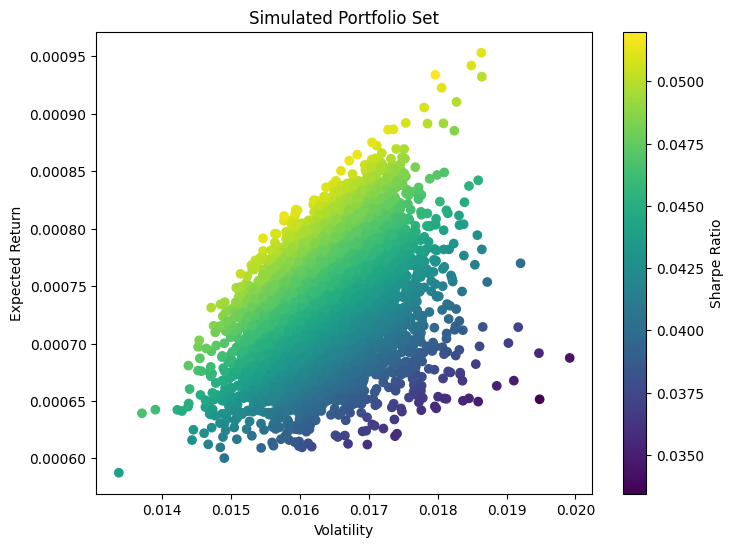

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(vol_list, returns_list, c=sharpe_list, cmap="viridis")
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Simulated Portfolio Set")
plt.colorbar(label="Sharpe Ratio")
plt.show()

## 9. Identify the maximum Sharpe ratio portfolio

Among all simulated portfolios, we now select the one with the highest Sharpe ratio.

This portfolio is the best risk-adjusted portfolio among the simulated points, although at this stage it is only an approximation, since we are searching over random portfolios rather than solving the exact optimization problem.

In [13]:
sharpe_array = np.array(sharpe_list, dtype=float)
max_idx = np.argmax(sharpe_array)

optimal_weights = results[max_idx][3]
optimal_return = results[max_idx][0]
optimal_vol = results[max_idx][1]
optimal_sharpe = results[max_idx][2]

print("Maximum Sharpe portfolio:")
for i, w in enumerate(optimal_weights):
    print(tickers[i], round(w, 3))

print("Expected return:", optimal_return)
print("Volatility:", optimal_vol)
print("Sharpe ratio:", optimal_sharpe)

Maximum Sharpe portfolio:
AAPL 0.309
MSFT 0.023
GOOG 0.624
AMZN 0.024
SPY 0.02
Expected return: 0.0009340287699612378
Volatility: 0.0179653823449376
Sharpe ratio: 0.051990475461516375


**Explanation**:

-	np.argmax(sharpe_array) returns the index of the portfolio with the highest Sharpe ratio.
-	The corresponding return, volatility, and weights are then extracted.

## 10. Compare with the equal-weight portfolio

A natural benchmark is the equal-weight portfolio, in which each asset receives the same allocation:

$$
w_i = \frac{1}{n}.
$$

This provides a simple baseline against which we can compare the optimized portfolio.

In [14]:
equal_weights = np.ones(len(tickers)) / len(tickers)

eq_return, eq_vol = portfolio_performance(equal_weights, mean_returns, cov_matrix)
eq_sharpe = eq_return / eq_vol

print("Equal-weight portfolio:")
for i, w in enumerate(equal_weights):
    print(tickers[i], round(w, 3))

print("Expected return:", eq_return)
print("Volatility:", eq_vol)
print("Sharpe ratio:", eq_sharpe)

Equal-weight portfolio:
AAPL 0.2
MSFT 0.2
GOOG 0.2
AMZN 0.2
SPY 0.2
Expected return: 0.0007332194114261173
Volatility: 0.01613511469648266
Sharpe ratio: 0.045442466646112775


## 11. Highlight the maximum Sharpe portfolio

We now plot the simulated portfolio set again and highlight the maximum Sharpe ratio portfolio with a red cross.

This allows us to visually identify where the best simulated risk-adjusted portfolio lies within the opportunity set.

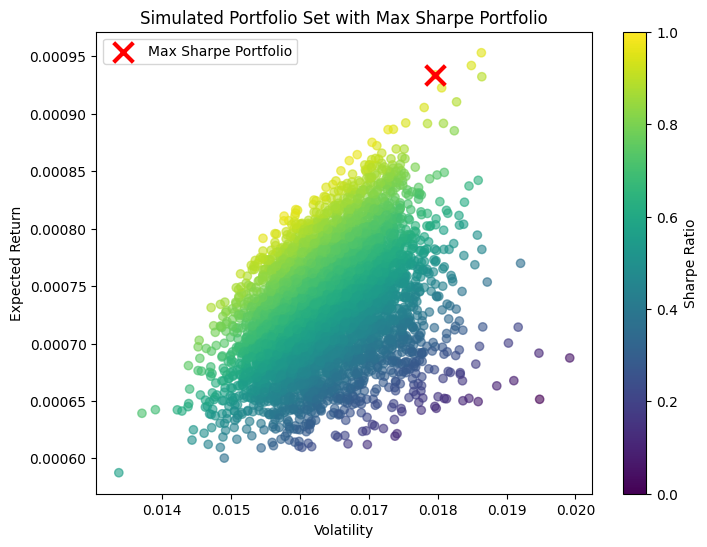

In [15]:
plt.figure(figsize=(8,6))

# Efficient frontier
plt.scatter(vol_list, returns_list, c=sharpe_list, cmap="viridis", alpha=0.6)

# Highlight optimal portfolio
plt.scatter(optimal_vol, optimal_return,
            color="red", marker="x", s=200, linewidths=3,
            label="Max Sharpe Portfolio")

# Labels
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Simulated Portfolio Set with Max Sharpe Portfolio")

# Colorbar
plt.colorbar(label="Sharpe Ratio")

# Legend
plt.legend()

plt.show()

## 12. Minimum-variance portfolio

We now move from simulation to true optimization.

The first exact optimization problem in the Markowitz framework is the **minimum-variance portfolio**. Its goal is to find the portfolio weights that minimize portfolio variance, independently of expected return.

If $w$ denotes the vector of portfolio weights and $\Sigma$ the covariance matrix of asset returns, then the portfolio variance is

$$
w^\top \Sigma w.
$$

We solve the optimization problem

$$
\min_w \; w^\top \Sigma w
$$

subject to

$$
\sum_{i=1}^n w_i = 1.
$$

In the long-only case,

$$
w_i \ge 0 \quad \text{for all } i.
$$

This portfolio is important because it provides the least risky feasible allocation among the assets considered.

In [16]:
from scipy.optimize import minimize

**Explanation**: `minimize` is a numerical optimization function from SciPy.

In [17]:
def minimize_variance(cov_matrix):
    num_assets = len(cov_matrix)

    # Initial guess: equal weights
    initial_weights = np.ones(num_assets) / num_assets

    # Constraint: weights must sum to 1
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    )

    # Bounds: no short selling, so each weight is between 0 and 1
    bounds = tuple((0, 1) for _ in range(num_assets))

    # Minimize portfolio volatility
    result = minimize(
        portfolio_volatility,
        initial_weights,
        args=(cov_matrix,),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    return result

In [18]:
min_var_result = minimize_variance(cov_matrix)

print(min_var_result)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.012943546834490482
           x: [ 0.000e+00  5.204e-18  0.000e+00  0.000e+00  1.000e+00]
         nit: 13
         jac: [ 1.543e-02  1.476e-02  1.461e-02  1.476e-02  1.294e-02]
        nfev: 78
        njev: 13
 multipliers: [ 1.461e-02]


In [19]:
min_var_weights = min_var_result.x
min_var_return, min_var_vol = portfolio_performance(min_var_weights, mean_returns, cov_matrix)
min_var_sharpe = min_var_return / min_var_vol

print("Minimum-variance portfolio:")
for i, w in enumerate(min_var_weights):
    print(tickers[i], round(w, 4))

print("Expected return:", min_var_return)
print("Volatility:", min_var_vol)
print("Sharpe ratio:", min_var_sharpe)

Minimum-variance portfolio:
AAPL 0.0
MSFT 0.0
GOOG 0.0
AMZN 0.0
SPY 1.0
Expected return: 0.000551966185206212
Volatility: 0.012943546834490482
Sharpe ratio: 0.04264412160470542


### Interpretation of the minimum-variance portfolio

The minimum-variance portfolio is the portfolio with the lowest feasible volatility among all long-only allocations whose weights sum to 1.

In this case, the optimizer assigns essentially 100% of the weight to SPY. This means that, among the selected assets, SPY alone has the smallest volatility, and no long-only combination of the assets is able to reduce portfolio risk further.

This is reasonable, since SPY is a broad market ETF and is typically less volatile than individual large-cap technology stocks.

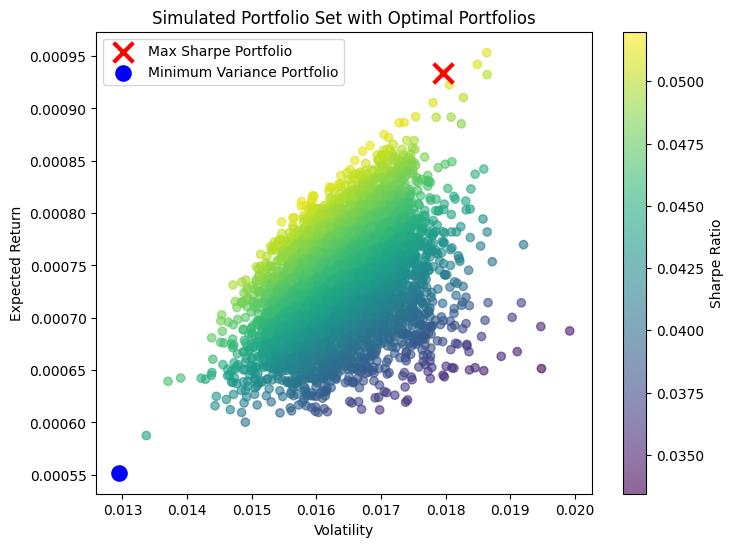

In [20]:
plt.figure(figsize=(8,6))

# Simulated portfolio set
scatter = plt.scatter(vol_list, returns_list, c=sharpe_list, cmap="viridis", alpha=0.6)

# Max Sharpe portfolio
plt.scatter(optimal_vol, optimal_return,
            color="red", marker="x", s=200, linewidths=3,
            label="Max Sharpe Portfolio")

# Minimum-variance portfolio
plt.scatter(min_var_vol, min_var_return,
            color="blue", marker="o", s=120,
            label="Minimum Variance Portfolio")

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Simulated Portfolio Set with Optimal Portfolios")
plt.colorbar(scatter, label="Sharpe Ratio")
plt.legend()
plt.show()

## 13. Efficient frontier

We now compute the **true efficient frontier**.

The efficient frontier is the set of portfolios with the lowest possible volatility for a given target return.

For each target return $ \mu^\star $, we solve the optimization problem

$$
\min_w \; w^\top \Sigma w
$$

subject to

$$
\sum_{i=1}^n w_i = 1,
\qquad
w^\top \mu = \mu^\star,
\qquad
w_i \ge 0.
$$

The resulting curve forms the upper-left boundary of the feasible portfolio set in the return-volatility plane.

This is one of the central objects in Markowitz portfolio theory.

In [21]:
def minimize_volatility_for_target_return(target_return, mean_returns, cov_matrix):
    num_assets = len(mean_returns)

    # Initial guess: equal weights
    initial_weights = np.ones(num_assets) / num_assets

    # Constraints:
    # 1) weights sum to 1
    # 2) portfolio return equals the target return
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: portfolio_return(w, mean_returns) - target_return}
    )

    # Bounds: long-only portfolio
    bounds = tuple((0, 1) for _ in range(num_assets))

    result = minimize(
        portfolio_volatility,
        initial_weights,
        args=(cov_matrix,),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    return result

In [100]:
target_returns = np.linspace(0, mean_returns.max(), 50)

In [101]:
frontier_returns = []
frontier_volatility = []
frontier_weights = []

for target in target_returns:
    result = minimize_volatility_for_target_return(target, mean_returns, cov_matrix)

    if result.success:
        frontier_returns.append(target)
        frontier_volatility.append(result.fun)
        frontier_weights.append(result.x)

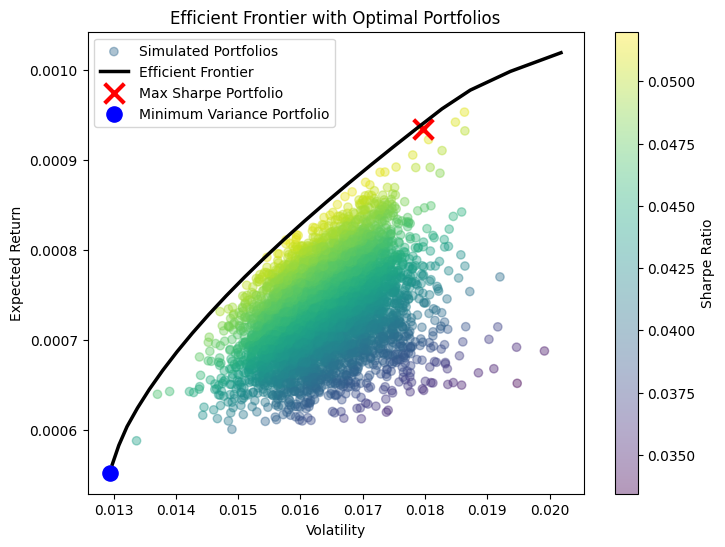

In [102]:
plt.figure(figsize=(8,6))

# Simulated portfolio set
scatter = plt.scatter(vol_list, returns_list, c=sharpe_list, cmap="viridis", alpha=0.4, label="Simulated Portfolios")

# Efficient frontier
plt.plot(frontier_volatility, frontier_returns, color="black", linewidth=2.5, label="Efficient Frontier")

# Max Sharpe portfolio
plt.scatter(optimal_vol, optimal_return,
            color="red", marker="x", s=200, linewidths=3,
            label="Max Sharpe Portfolio")

# Minimum-variance portfolio
plt.scatter(min_var_vol, min_var_return,
            color="blue", marker="o", s=120,
            label="Minimum Variance Portfolio")

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier with Optimal Portfolios")
plt.colorbar(scatter, label="Sharpe Ratio")
plt.legend()
plt.show()

### Interpretation of the efficient frontier

The black curve represents the true efficient frontier, obtained by solving a constrained optimization problem for each target return.

Each point on this curve corresponds to the lowest possible volatility for a given expected return. The blue point is the minimum-variance portfolio, while the red cross marks the portfolio with the highest Sharpe ratio among the simulated portfolios.

The efficient frontier forms the optimal boundary of the feasible portfolio set.

## 14. Exact maximum-Sharpe portfolio

We now compute the exact maximum-Sharpe portfolio.

The Sharpe ratio measures return per unit of risk. Assuming a zero risk-free rate, it is defined by

$$
\text{Sharpe}(w)=\frac{w^\top \mu}{\sqrt{w^\top \Sigma w}}.
$$

The goal is to find the portfolio weights \(w\) that maximize this quantity, subject to the portfolio being fully invested and long-only:

$$
\sum_{i=1}^n w_i = 1, \qquad w_i \ge 0.
$$

Since numerical optimizers typically minimize objective functions, we instead minimize the negative Sharpe ratio.

In [103]:
def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate=0):
    ret = portfolio_return(weights, mean_returns)
    vol = portfolio_volatility(weights, cov_matrix)
    return -(ret - risk_free_rate) / vol

In [104]:
def maximize_sharpe(mean_returns, cov_matrix, risk_free_rate=0):
    num_assets = len(mean_returns)

    # Initial guess: equal weights
    initial_weights = np.ones(num_assets) / num_assets

    # Constraint: weights sum to 1
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    )

    # Bounds: long-only portfolio
    bounds = tuple((0, 1) for _ in range(num_assets))

    result = minimize(
        negative_sharpe,
        initial_weights,
        args=(mean_returns, cov_matrix, risk_free_rate),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    return result

In [105]:
max_sharpe_result = maximize_sharpe(mean_returns, cov_matrix)

print(max_sharpe_result)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -0.052374712735930834
           x: [ 3.044e-01  0.000e+00  6.798e-01  3.079e-17  1.586e-02]
         nit: 17
         jac: [-1.494e-04  9.644e-03  6.740e-05  4.535e-03 -1.179e-04]
        nfev: 103
        njev: 17
 multipliers: [-9.091e-06]


In [106]:
exact_max_sharpe_weights = max_sharpe_result.x
exact_max_sharpe_return = portfolio_return(exact_max_sharpe_weights, mean_returns)
exact_max_sharpe_vol = portfolio_volatility(exact_max_sharpe_weights, cov_matrix)
exact_max_sharpe_ratio = (exact_max_sharpe_return / exact_max_sharpe_vol)

print("Exact maximum-Sharpe portfolio:")
for i, w in enumerate(exact_max_sharpe_weights):
    print(tickers[i], round(w, 4))

print("Expected return:", exact_max_sharpe_return)
print("Volatility:", exact_max_sharpe_vol)
print("Sharpe ratio:", exact_max_sharpe_ratio)

Exact maximum-Sharpe portfolio:
AAPL 0.3044
MSFT 0.0
GOOG 0.6798
AMZN 0.0
SPY 0.0159
Expected return: 0.000955338096716597
Volatility: 0.018240445566419357
Sharpe ratio: 0.052374712735930834


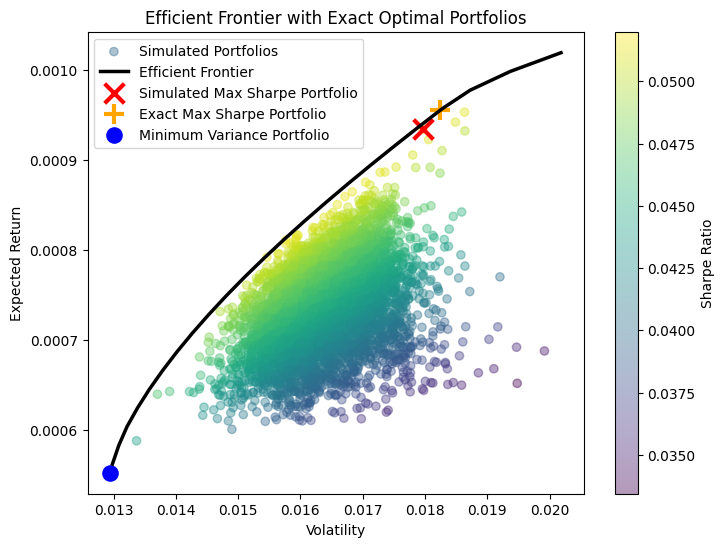

In [107]:
plt.figure(figsize=(8,6))

# Simulated portfolio set
scatter = plt.scatter(vol_list, returns_list, c=sharpe_list, cmap="viridis", alpha=0.4, label="Simulated Portfolios")

# Efficient frontier
plt.plot(frontier_volatility, frontier_returns, color="black", linewidth=2.5, label="Efficient Frontier")

# Simulated Max Sharpe portfolio
plt.scatter(optimal_vol, optimal_return,
            color="red", marker="x", s=200, linewidths=3,
            label="Simulated Max Sharpe Portfolio")

# Exact max Sharpe portfolio
plt.scatter(exact_max_sharpe_vol, exact_max_sharpe_return,
            color="orange", marker="+", s=220, linewidths=3,
            label="Exact Max Sharpe Portfolio")

# Minimum-variance portfolio
plt.scatter(min_var_vol, min_var_return,
            color="blue", marker="o", s=120,
            label="Minimum Variance Portfolio")

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier with Exact Optimal Portfolios")
plt.colorbar(scatter, label="Sharpe Ratio")
plt.legend()
plt.show()

### Interpretation of the exact maximum-Sharpe portfolio

The orange cross represents the exact maximum-Sharpe portfolio, obtained via constrained optimization rather than random simulation.

It lies on the efficient frontier, which is expected, since the portfolio with the best risk-adjusted performance must be an efficient portfolio. This portfolio balances expected return and volatility in an optimal way under the long-only constraint.

## 16. Closed-form maximum-Sharpe portfolio

In the case of a zero risk-free rate and without long-only constraints, the maximum-Sharpe portfolio admits a closed-form expression.

If $\mu$ denotes the expected return vector and $\Sigma$ the covariance matrix, then the optimal weights are proportional to

$$
\Sigma^{-1}\mu.
$$

To obtain a fully invested portfolio whose weights sum to 1, we normalize this vector:

$$
w^\star = \frac{\Sigma^{-1}\mu}{\mathbf{1}^\top \Sigma^{-1}\mu}.
$$

This analytical formula provides a useful benchmark against which we can compare the numerically optimized long-only maximum-Sharpe portfolio.

In [108]:
ones = np.ones(len(tickers))

inv_cov_matrix = np.linalg.inv(cov_matrix)
analytical_max_sharpe_weights = inv_cov_matrix @ mean_returns
analytical_max_sharpe_weights = analytical_max_sharpe_weights / np.sum(analytical_max_sharpe_weights)

print("Analytical max-Sharpe weights (unconstrained):")
for i, w in enumerate(analytical_max_sharpe_weights):
    print(tickers[i], round(w, 4))

Analytical max-Sharpe weights (unconstrained):
AAPL 0.3486
MSFT -0.2106
GOOG 0.7641
AMZN -0.1709
SPY 0.2688


In [109]:
analytical_return = portfolio_return(analytical_max_sharpe_weights, mean_returns)
analytical_vol = portfolio_volatility(analytical_max_sharpe_weights, cov_matrix)
analytical_sharpe = analytical_return / analytical_vol

print("Analytical max-Sharpe portfolio:")
print("Expected return:", analytical_return)
print("Volatility:", analytical_vol)
print("Sharpe ratio:", analytical_sharpe)

Analytical max-Sharpe portfolio:
Expected return: 0.0009778300740216966
Volatility: 0.018167458349691152
Sharpe ratio: 0.053823163108466396


In [110]:
print("Comparison of weights:")
for i in range(len(tickers)):
    print(
        tickers[i],
        "| exact long-only =", round(exact_max_sharpe_weights[i], 4),
        "| analytical unconstrained =", round(analytical_max_sharpe_weights[i], 4)
    )

Comparison of weights:
AAPL | exact long-only = 0.3044 | analytical unconstrained = 0.3486
MSFT | exact long-only = 0.0 | analytical unconstrained = -0.2106
GOOG | exact long-only = 0.6798 | analytical unconstrained = 0.7641
AMZN | exact long-only = 0.0 | analytical unconstrained = -0.1709
SPY | exact long-only = 0.0159 | analytical unconstrained = 0.2688


In [111]:
weight_difference = exact_max_sharpe_weights - analytical_max_sharpe_weights
distance_l2 = np.linalg.norm(weight_difference)

print("Weight difference vector:", weight_difference)
print("L2 distance between the two allocations:", distance_l2)

Weight difference vector: [-0.04422772  0.21060508 -0.08432648  0.17086322 -0.25291409]
L2 distance between the two allocations: 0.38285940100886956


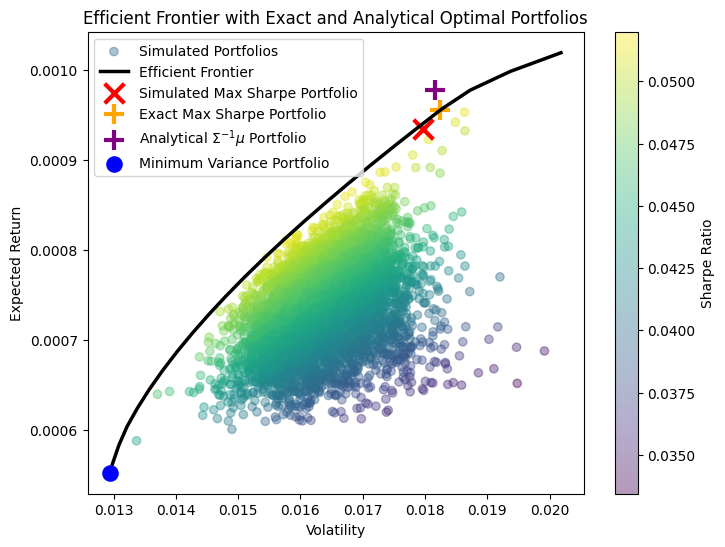

In [112]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(vol_list, returns_list, c=sharpe_list, cmap="viridis", alpha=0.4, label="Simulated Portfolios")
plt.plot(frontier_volatility, frontier_returns, color="black", linewidth=2.5, label="Efficient Frontier")

# Simulated Max Sharpe portfolio
plt.scatter(optimal_vol, optimal_return,
            color="red", marker="x", s=200, linewidths=3,
            label="Simulated Max Sharpe Portfolio")

plt.scatter(exact_max_sharpe_vol, exact_max_sharpe_return,
            color="orange", marker="+", s=220, linewidths=3,
            label="Exact Max Sharpe Portfolio")

plt.scatter(analytical_vol, analytical_return,
            color="purple", marker="+", s=220, linewidths=3,
            label="Analytical $\\Sigma^{-1}\\mu$ Portfolio")

plt.scatter(min_var_vol, min_var_return,
            color="blue", marker="o", s=120,
            label="Minimum Variance Portfolio")

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier with Exact and Analytical Optimal Portfolios")
plt.colorbar(scatter, label="Sharpe Ratio")
plt.legend()
plt.show()

### Comparison with the analytical solution

The unconstrained maximum-Sharpe portfolio is proportional to $\Sigma^{-1}\mu$, while the numerical optimizer computes the exact long-only maximum-Sharpe portfolio under the constraints $w_i \ge 0$ and $\sum_i w_i = 1$.

Comparing the two solutions helps illustrate the effect of portfolio constraints. If the two portfolios are close, then the unconstrained analytical solution is already nearly feasible. If they differ significantly, this indicates that the long-only restriction materially changes the optimal allocation.

### Effect of constraints on the optimal portfolio

The analytical maximum-Sharpe portfolio is proportional to $\Sigma^{-1}\mu$ and does not enforce any constraints on the weights.

In particular, it may include negative weights (short positions). As a result, it belongs to a larger feasible set than the long-only portfolios considered in the optimization.

This explains why the analytical portfolio can lie above the long-only efficient frontier: it achieves a better risk-return trade-off by allowing short selling.

In contrast, the numerically optimized maximum-Sharpe portfolio respects the long-only constraints $w_i \ge 0$, and therefore lies on the corresponding efficient frontier.

## 17. Allowing short selling

We now relax the long-only constraint and allow portfolio weights to take negative values.

This corresponds to allowing short selling, meaning that we can take negative positions in some assets and offset them with larger positive positions in others.

The optimization problems now become:

### Minimum-variance portfolio
$$
\min_w \; w^\top \Sigma w
\quad \text{subject to} \quad \sum_i w_i = 1
$$

### Efficient frontier
$$
\min_w \; w^\top \Sigma w
\quad \text{subject to} \quad \sum_i w_i = 1,\quad w^\top \mu = \mu^\star
$$

### Maximum Sharpe portfolio
$$
\max_w \; \frac{w^\top \mu}{\sqrt{w^\top \Sigma w}}
\quad \text{subject to} \quad \sum_i w_i = 1
$$

In this unconstrained setting, the analytical solution $\Sigma^{-1} \mu$ is expected to coincide with the maximum-Sharpe portfolio.

In [113]:
def minimize_variance_short(cov_matrix):
    num_assets = len(cov_matrix)

    initial_weights = np.ones(num_assets) / num_assets

    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    )

    result = minimize(
        portfolio_volatility,
        initial_weights,
        args=(cov_matrix,),
        method='SLSQP',
        bounds=None,
        constraints=constraints
    )

    return result

In [114]:
def minimize_volatility_for_target_return_short(target_return, mean_returns, cov_matrix):
    num_assets = len(mean_returns)

    initial_weights = np.ones(num_assets) / num_assets

    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: portfolio_return(w, mean_returns) - target_return}
    )

    result = minimize(
        portfolio_volatility,
        initial_weights,
        args=(cov_matrix,),
        method='SLSQP',
        bounds=None,
        constraints=constraints
    )

    return result

In [115]:
def maximize_sharpe_short(mean_returns, cov_matrix, risk_free_rate=0):
    num_assets = len(mean_returns)

    initial_weights = np.ones(num_assets) / num_assets

    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    )

    result = minimize(
        negative_sharpe,
        initial_weights,
        args=(mean_returns, cov_matrix, risk_free_rate),
        method='SLSQP',
        bounds=None,
        constraints=constraints
    )

    return result

In [116]:
target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 50)

frontier_returns_short = []
frontier_vol_short = []

for target in target_returns:
    result = minimize_volatility_for_target_return_short(target, mean_returns, cov_matrix)

    if result.success:
        frontier_returns_short.append(target)
        frontier_vol_short.append(result.fun)

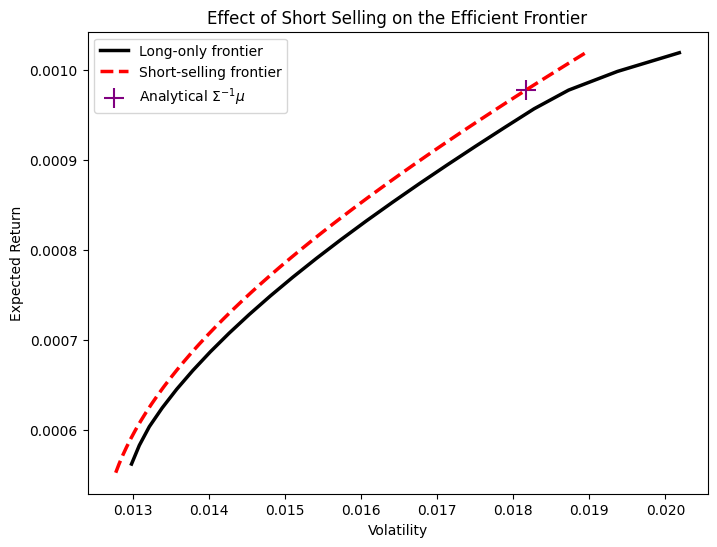

In [117]:
plt.figure(figsize=(8,6))

# Long-only frontier
plt.plot(frontier_volatility, frontier_returns,
         color="black", linewidth=2.5, label="Long-only frontier")

# Short-selling frontier
plt.plot(frontier_vol_short, frontier_returns_short,
         color="red", linestyle="--", linewidth=2.5, label="Short-selling frontier")

# Analytical solution
plt.scatter(analytical_vol, analytical_return,
            color="purple", marker="+", s=220, label="Analytical $\\Sigma^{-1}\\mu$")

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Effect of Short Selling on the Efficient Frontier")
plt.legend()
plt.show()

### Effect of short selling

Allowing short selling enlarges the feasible set of portfolios. As a result, the efficient frontier shifts upward, meaning that for a given level of risk, higher returns can be achieved.

In this unconstrained setting, the analytical solution $\Sigma^{-1}\mu$ coincides with the maximum-Sharpe portfolio and lies on the efficient frontier.

This highlights the strong impact of constraints on optimal portfolio allocation.

### Comparison of constrained and unconstrained efficient frontiers

The unconstrained efficient frontier lies strictly above the long-only frontier, reflecting the fact that allowing short selling enlarges the feasible set of portfolios.

The analytical solution $ \Sigma^{-1}\mu $ lies on the unconstrained frontier, confirming that it is the true maximum-Sharpe portfolio in the absence of constraints.

This comparison highlights the significant impact of portfolio constraints on optimal allocations and achievable performance.

In [118]:
#print(analytical_max_sharpe_weights)

## 18. Extended unconstrained efficient frontier for the Capital Market Line

To visualize the Capital Market Line correctly, we need the unconstrained efficient frontier over a sufficiently large range of target returns.

When short selling is allowed, the set of achievable portfolio returns is no longer bounded by the returns of individual assets. In particular, the tangency portfolio may have a return larger than the maximum individual asset return.

For this reason, we recompute the unconstrained efficient frontier over an extended range of target returns before plotting the CML.

In [119]:
target_returns_cml = np.linspace(0, mean_returns.max() * 3, 150)

frontier_returns_cml = []
frontier_vol_cml = []

for target in target_returns_cml:
    result = minimize_volatility_for_target_return_short(target, mean_returns, cov_matrix)

    if result.success:
        frontier_returns_cml.append(target)
        frontier_vol_cml.append(result.fun)

## 18. Risk-free rate and the Capital Market Line

We now introduce a nonzero risk-free rate \(r_f\).

With a risk-free asset, the Sharpe ratio of a portfolio becomes

$$
\text{Sharpe}(w)=\frac{w^\top \mu-r_f}{\sqrt{w^\top \Sigma w}}.
$$

The portfolio that maximizes this ratio is called the **tangency portfolio**.

In the unconstrained setting, the tangency portfolio is proportional to

$$
\Sigma^{-1}(\mu-r_f\mathbf{1}),
$$

where $\mathbf{1}$ is the vector of ones.

Once the tangency portfolio is known, combining it with the risk-free asset gives the **Capital Market Line (CML)**:

$$
\mathbb{E}[R] = r_f + \text{Sharpe}_{\max}\,\sigma.
$$

The CML is the line through the risk-free point that is tangent to the efficient frontier.

In [120]:
risk_free_rate_annual = 0.04
risk_free_rate_daily = risk_free_rate_annual / 252

print("Daily risk-free rate:", risk_free_rate_daily)

Daily risk-free rate: 0.00015873015873015873


In [121]:
max_sharpe_rf_result = maximize_sharpe_short(mean_returns, cov_matrix, risk_free_rate=risk_free_rate_daily)

rf_max_sharpe_weights = max_sharpe_rf_result.x
rf_max_sharpe_return = portfolio_return(rf_max_sharpe_weights, mean_returns)
rf_max_sharpe_vol = portfolio_volatility(rf_max_sharpe_weights, cov_matrix)
rf_max_sharpe_ratio = (rf_max_sharpe_return - risk_free_rate_daily) / rf_max_sharpe_vol

print("Exact maximum-Sharpe portfolio with risk-free rate:")
for i, w in enumerate(rf_max_sharpe_weights):
    print(tickers[i], round(w, 4))

print("Expected return:", rf_max_sharpe_return)
print("Volatility:", rf_max_sharpe_vol)
print("Sharpe ratio:", rf_max_sharpe_ratio)

Exact maximum-Sharpe portfolio with risk-free rate:
AAPL 0.6131
MSFT -0.2913
GOOG 1.1304
AMZN -0.2684
SPY -0.1837
Expected return: 0.001209173769649747
Volatility: 0.02285413495571802
Sharpe ratio: 0.04596295650458523


In [122]:
ones = np.ones(len(tickers))
excess_returns = mean_returns - risk_free_rate_daily * ones

inv_cov_matrix = np.linalg.inv(cov_matrix)
analytical_tangency_weights = inv_cov_matrix @ excess_returns
analytical_tangency_weights = analytical_tangency_weights / np.sum(analytical_tangency_weights)

analytical_tangency_return = portfolio_return(analytical_tangency_weights, mean_returns)
analytical_tangency_vol = portfolio_volatility(analytical_tangency_weights, cov_matrix)
analytical_tangency_sharpe = (analytical_tangency_return - risk_free_rate_daily) / analytical_tangency_vol

In [123]:
print("Analytical tangency portfolio:")
for i, w in enumerate(analytical_tangency_weights):
    print(tickers[i], round(w, 4))

print("Expected return:", analytical_tangency_return)
print("Volatility:", analytical_tangency_vol)
print("Sharpe ratio:", analytical_tangency_sharpe)

Analytical tangency portfolio:
AAPL 0.6128
MSFT -0.3048
GOOG 1.1849
AMZN -0.205
SPY -0.288
Expected return: 0.0012397625942855623
Volatility: 0.023500800968181704
Sharpe ratio: 0.0459998123901836


In [124]:
print("Tangency volatility:", analytical_tangency_vol)
print("Max volatility on extended frontier:", max(frontier_vol_cml))
print("Tangency return:", analytical_tangency_return)
print("Max return on extended frontier:", max(frontier_returns_cml))

Tangency volatility: 0.023500800968181704
Max volatility on extended frontier: 0.06783381960473871
Tangency return: 0.0012397625942855623
Max return on extended frontier: 0.003057804074664415


In [125]:
cml_x = np.linspace(0, 0.04, 100)
cml_y = risk_free_rate_daily + analytical_tangency_sharpe * cml_x

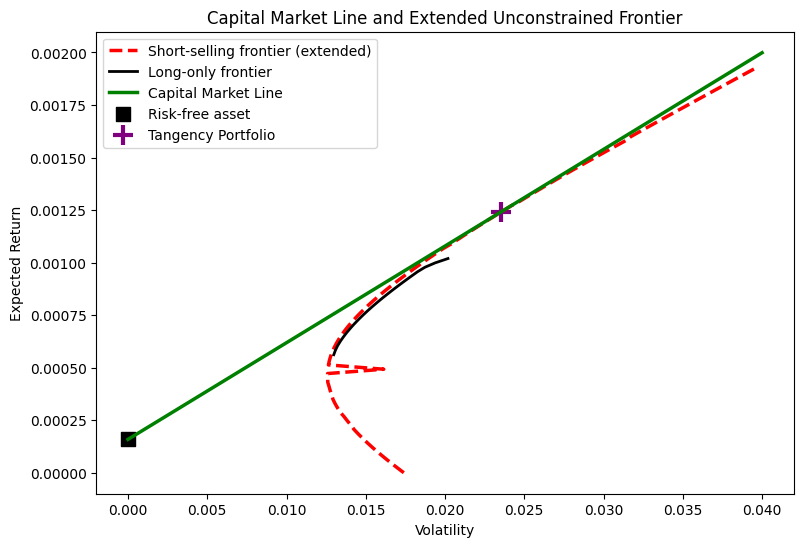

In [126]:
plt.figure(figsize=(9,6))

mask = np.array(frontier_vol_cml) < 0.04
# Extended unconstrained frontier
plt.plot(np.array(frontier_vol_cml)[mask],
         np.array(frontier_returns_cml)[mask],
         color="red", linestyle="--", linewidth=2.5,
         label="Short-selling frontier (extended)")

# Long-only frontier
plt.plot(frontier_volatility, frontier_returns,
         color="black", linewidth=2.0,
         label="Long-only frontier")

# Capital Market Line
plt.plot(cml_x, cml_y,
         color="green", linewidth=2.5,
         label="Capital Market Line")

# Risk-free point
plt.scatter(0, risk_free_rate_daily,
            color="black", marker="s", s=100,
            label="Risk-free asset")

# Tangency portfolio
plt.scatter(analytical_tangency_vol, analytical_tangency_return,
            color="purple", marker="+", s=220, linewidths=3,
            label="Tangency Portfolio")

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Capital Market Line and Extended Unconstrained Frontier")
plt.legend()
plt.show()

### Remarks on the efficient frontier and the Capital Market Line

The unconstrained efficient frontier can, in principle, extend to very low returns when short selling is allowed. In this notebook, we restrict the range of target returns for visualization purposes.

The Capital Market Line (CML), on the other hand, is unbounded: by combining the risk-free asset with leveraged positions in the tangency portfolio, arbitrarily high levels of risk and return can be achieved.

## 20. Sensitivity to estimation errors

So far, we have assumed that the expected returns $\mu$ and covariance matrix $\Sigma$ are known exactly.

In practice, these quantities must be estimated from historical data, and are subject to statistical noise. In particular, the estimation of expected returns is highly unstable.

Since the maximum-Sharpe portfolio depends on the expression

$$
w^\star \propto \Sigma^{-1}\mu,
$$

small errors in the estimation of $\mu$ can lead to large changes in the optimal weights.

We now investigate the sensitivity of the optimal portfolio to perturbations in the estimated returns.

In [145]:
np.random.seed(42)

noise_level = 0.0002  # adjust this later

perturbed_mean_returns = mean_returns + noise_level * np.random.randn(len(mean_returns))

In [146]:
perturbed_result = maximize_sharpe(mean_returns=perturbed_mean_returns, cov_matrix=cov_matrix)

perturbed_weights = perturbed_result.x

In [147]:
print("Original weights:")
print(exact_max_sharpe_weights)

print("\nPerturbed weights:")
print(perturbed_weights)

print("\nDifference:")
print(perturbed_weights - exact_max_sharpe_weights)

Original weights:
[3.04370079e-01 0.00000000e+00 6.79766975e-01 3.07913417e-17
 1.58629464e-02]

Perturbed weights:
[1.79264969e-01 4.13898758e-17 5.55235584e-01 2.65499447e-01
 8.78680390e-18]

Difference:
[-1.25105110e-01  4.13898758e-17 -1.24531391e-01  2.65499447e-01
 -1.58629464e-02]


In [148]:
diff_norm = np.linalg.norm(perturbed_weights - exact_max_sharpe_weights)

print("L2 difference:", diff_norm)

L2 difference: 0.319219274648785


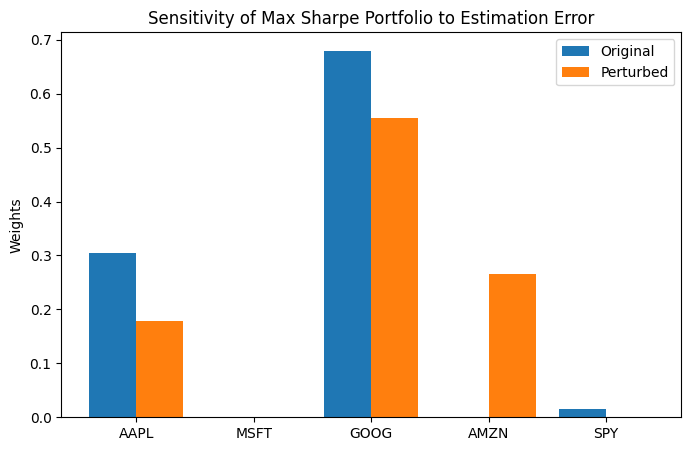

In [149]:
x = np.arange(len(tickers))

plt.figure(figsize=(8,5))

plt.bar(x - 0.2, exact_max_sharpe_weights, width=0.4, label="Original")
plt.bar(x + 0.2, perturbed_weights, width=0.4, label="Perturbed")

plt.xticks(x, tickers)
plt.ylabel("Weights")
plt.title("Sensitivity of Max Sharpe Portfolio to Estimation Error")
plt.legend()
plt.show()

### Instability of the maximum-Sharpe portfolio

We observe that even a very small perturbation in the estimated mean returns leads to a drastic change in the optimal portfolio weights.

In particular, the allocation shifts from a diversified portfolio to a highly concentrated one, dominated by a single asset.

This behavior reflects the well-known instability of mean-variance optimization, which tends to amplify estimation errors and produce extreme allocations.

In practice, this makes naive maximum-Sharpe portfolios unreliable and motivates the use of more robust portfolio construction methods.

## 21. Full instability analysis of the maximum-Sharpe portfolio

We now extend the previous sensitivity experiment by repeating it many times.

Instead of perturbing the estimated mean returns only once, we generate multiple noisy versions of the return vector $\mu$, recompute the maximum-Sharpe portfolio each time, and compare the resulting optimal weights.

This allows us to assess the stability of the allocation under estimation error.

If the portfolio weights vary significantly across perturbations, this indicates that the optimization problem is highly unstable and sensitive to small changes in the estimated inputs.

In [150]:
np.random.seed(42)

num_simulations = 200
noise_level = 0.001

perturbed_weights_list = []

for _ in range(num_simulations):
    perturbed_mean_returns = mean_returns + noise_level * np.random.randn(len(mean_returns))
    perturbed_result = maximize_sharpe(mean_returns=perturbed_mean_returns, cov_matrix=cov_matrix)

    if perturbed_result.success:
        perturbed_weights_list.append(perturbed_result.x)

perturbed_weights_array = np.array(perturbed_weights_list)

print("Shape of perturbed weights array:", perturbed_weights_array.shape)

Shape of perturbed weights array: (200, 5)


In [151]:
mean_perturbed_weights = perturbed_weights_array.mean(axis=0)
std_perturbed_weights = perturbed_weights_array.std(axis=0)

print("Average perturbed weights:")
for i, w in enumerate(mean_perturbed_weights):
    print(tickers[i], round(w, 4))

print("\nStandard deviation of perturbed weights:")
for i, s in enumerate(std_perturbed_weights):
    print(tickers[i], round(s, 4))

Average perturbed weights:
AAPL 0.1911
MSFT 0.1179
GOOG 0.1871
AMZN 0.1916
SPY 0.3124

Standard deviation of perturbed weights:
AAPL 0.3475
MSFT 0.2616
GOOG 0.3323
AMZN 0.3469
SPY 0.4176


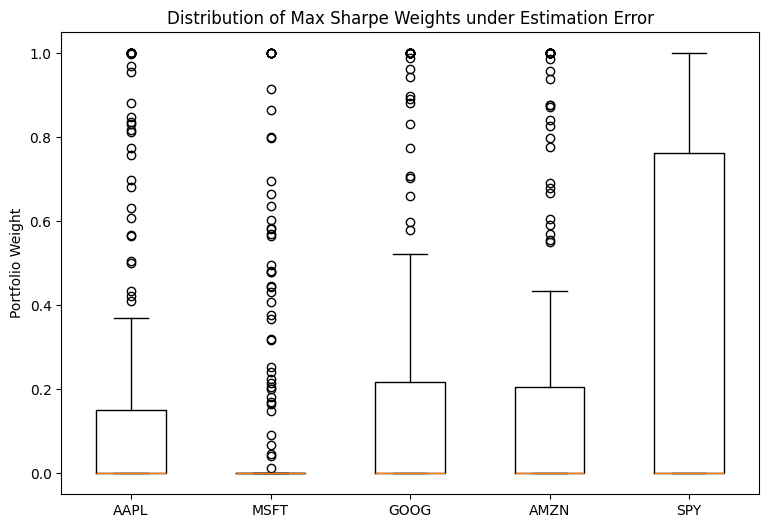

In [152]:
plt.figure(figsize=(9,6))
plt.boxplot([perturbed_weights_array[:, i] for i in range(len(tickers))], tick_labels=tickers)
plt.ylabel("Portfolio Weight")
plt.title("Distribution of Max Sharpe Weights under Estimation Error")
plt.show()

### Distribution of optimal weights under estimation error

This boxplot shows the distribution of the maximum-Sharpe portfolio weights across multiple perturbations of the estimated mean returns.

Each box summarizes the variability of the allocation to a given asset, including the median, interquartile range, and extreme values. We observe that, for all assets, the weights exhibit a wide dispersion: in many simulations the weight is close to zero, while in others it can become very large, sometimes close to one.

This indicates that each asset alternates between being effectively excluded from the portfolio and being assigned a dominant position. Such behavior reflects the tendency of the optimization procedure to concentrate the allocation on assets with slightly higher estimated returns.

Overall, the boxplot highlights the high sensitivity of the optimal portfolio to estimation errors, and the lack of stability in the resulting allocations.

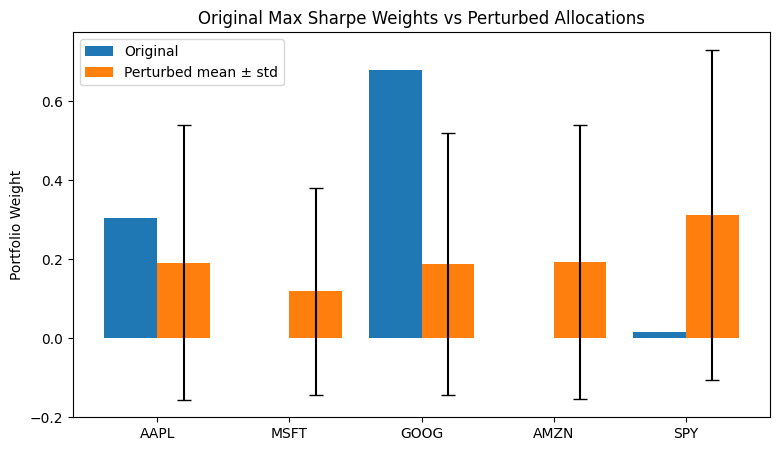

In [153]:
x = np.arange(len(tickers))

plt.figure(figsize=(9,5))
plt.bar(x - 0.2, exact_max_sharpe_weights, width=0.4, label="Original")
plt.bar(x + 0.2, mean_perturbed_weights, width=0.4, yerr=std_perturbed_weights, capsize=5, label="Perturbed mean ± std")

plt.xticks(x, tickers)
plt.ylabel("Portfolio Weight")
plt.title("Original Max Sharpe Weights vs Perturbed Allocations")
plt.legend()
plt.show()

### Comparison between original and perturbed allocations

This figure compares the original maximum-Sharpe portfolio with the average allocation obtained under repeated perturbations of the estimated mean returns. The error bars represent one standard deviation of the weights across simulations.

While the average perturbed allocation appears more diversified than the original portfolio, the large error bars indicate substantial variability in the weights. In many cases, the standard deviation is comparable to or larger than the mean, and the error bars span a wide range of possible values, including negative weights in some instances.

This shows that the average allocation is not representative of a stable portfolio, but rather reflects the aggregation of highly variable and inconsistent outcomes. In practice, this means that small changes in the estimated returns can lead to drastically different portfolio compositions.

This result emphasizes the instability of the maximum-Sharpe portfolio and the difficulty of relying on a single estimated optimal allocation.

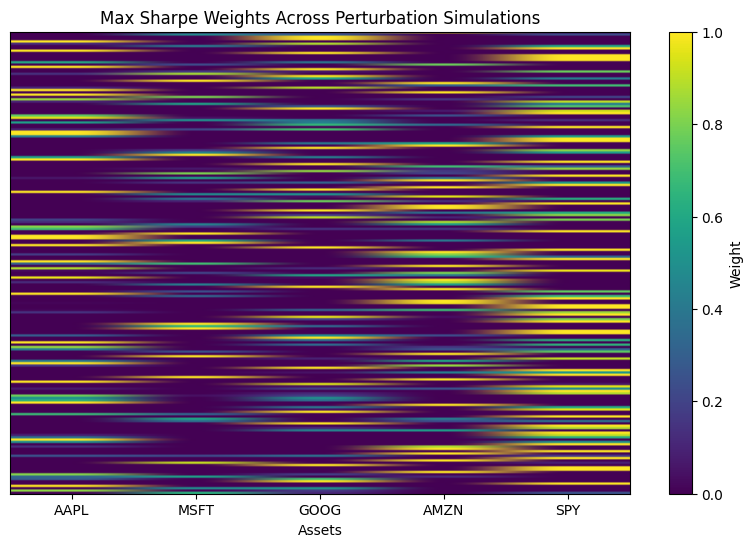

In [154]:
plt.figure(figsize=(10,6))
plt.imshow(perturbed_weights_array, aspect='auto')
plt.colorbar(label="Weight")
plt.yticks([])
plt.xticks(np.arange(len(tickers)), tickers)
plt.xlabel("Assets")
plt.title("Max Sharpe Weights Across Perturbation Simulations")
plt.show()

### Heatmap of portfolio weights across perturbations

This heatmap displays the optimal portfolio weights obtained across all perturbation simulations. Each row corresponds to one simulation, and each column to one asset. The color intensity represents the magnitude of the weight assigned to each asset.

The absence of a consistent pattern across rows indicates that the portfolio composition varies significantly from one simulation to another. In many cases, the allocation is highly concentrated on a single asset, while the others receive negligible weights. However, the identity of the dominant asset changes across simulations.

This behavior reflects the fact that small perturbations in the estimated mean returns can alter the relative ranking of assets, leading the optimizer to shift the entire allocation toward a different asset.

The heatmap provides a clear visual demonstration of the instability of the maximum-Sharpe portfolio, showing that the optimization process produces highly variable and non-robust allocations in the presence of estimation error.

### Overall interpretation

Taken together, these visualizations demonstrate that the maximum-Sharpe portfolio is highly sensitive to estimation error in the expected returns. Small perturbations lead to large and unpredictable changes in the optimal weights, often resulting in concentrated and unstable allocations.

This instability arises from the amplification of estimation errors through the optimization process, particularly due to the inversion of the covariance matrix and the extremal nature of the Sharpe ratio maximization.

These results highlight a key limitation of naive mean-variance optimization and motivate the use of more robust portfolio construction techniques in practice.

## 22. Stabilizing portfolio optimization

The instability observed in the previous section is mainly due to the sensitivity of the optimal portfolio to estimation errors in the expected returns.

To mitigate this issue, several approaches can be used. In this section, we consider two simple and widely used techniques:

- **Shrinkage** of the mean returns, which reduces the impact of estimation noise,
- **Regularization** of the optimization problem, which penalizes extreme portfolio weights.

These methods aim to produce more stable and diversified allocations, at the cost of a slight bias in the optimization.

### Shrinkage

Instead of using raw $\mu$, we shrink it toward something more stable. The simplest choice is to shrink toward the average return:

$$
\mu^{\text{shrunk}} = (1 - \alpha)\mu + \alpha \bar{\mu}.
$$

In [155]:
alpha = 0.5  # shrinkage intensity

mean_mean = np.mean(mean_returns)

shrunk_mean_returns = (1 - alpha) * mean_returns + alpha * mean_mean

In [156]:
shrunk_result = maximize_sharpe(mean_returns=shrunk_mean_returns, cov_matrix=cov_matrix)

shrunk_weights = shrunk_result.x

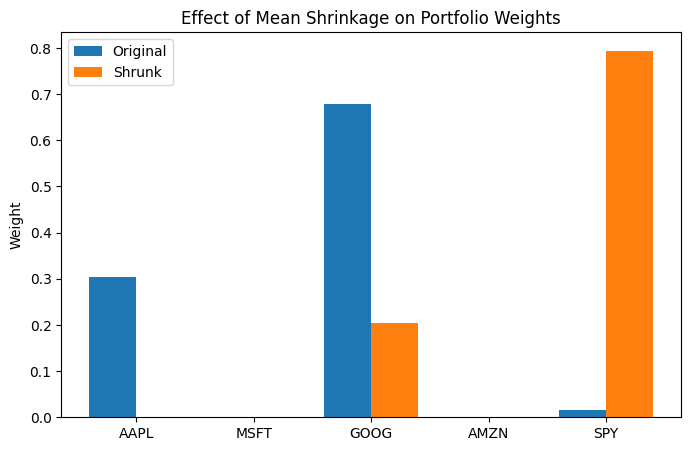

In [157]:
x = np.arange(len(tickers))

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, exact_max_sharpe_weights, width=0.4, label="Original")
plt.bar(x + 0.2, shrunk_weights, width=0.4, label="Shrunk")

plt.xticks(x, tickers)
plt.ylabel("Weight")
plt.title("Effect of Mean Shrinkage on Portfolio Weights")
plt.legend()
plt.show()

### Effect of mean shrinkage on portfolio allocation

This figure compares the original maximum-Sharpe portfolio with the portfolio obtained after applying shrinkage to the estimated mean returns.

Shrinkage consists in reducing the dispersion of the estimated returns by pulling them toward their average value. This limits the influence of estimation noise and prevents the optimizer from overreacting to small differences between assets.

In the original portfolio, the allocation is highly concentrated, with most of the weight assigned to a small number of assets. After shrinkage, the allocation shifts significantly, becoming more balanced across assets. In particular, the optimizer no longer concentrates exclusively on the asset with the highest estimated return, but distributes the weights more evenly.

This illustrates that shrinkage reduces the sensitivity of the optimization to noisy return estimates, leading to more stable and diversified portfolios, at the cost of introducing a small bias in the expected returns.

### Regularization

We modify the optimization in the following way: instead of maximizing the Sharpe ratio, we solve:

$$
\max_{w} \Big\{ \text{Sharpe} - \lambda w \Big\}.
$$

Hence, we penalize large weights.

In [158]:
def negative_sharpe_regularized(weights, mean_returns, cov_matrix, lambda_reg=0.1):
    ret = portfolio_return(weights, mean_returns)
    vol = portfolio_volatility(weights, cov_matrix)

    sharpe = ret / vol
    penalty = lambda_reg * np.sum(weights**2)

    return -(sharpe - penalty)

In [159]:
lambda_reg = 0.1

num_assets = len(mean_returns)
initial_weights = np.ones(num_assets) / num_assets

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)

result_reg = minimize(
    negative_sharpe_regularized,
    initial_weights,
    args=(mean_returns, cov_matrix, lambda_reg),
    method='SLSQP',
    constraints=constraints
)

reg_weights = result_reg.x

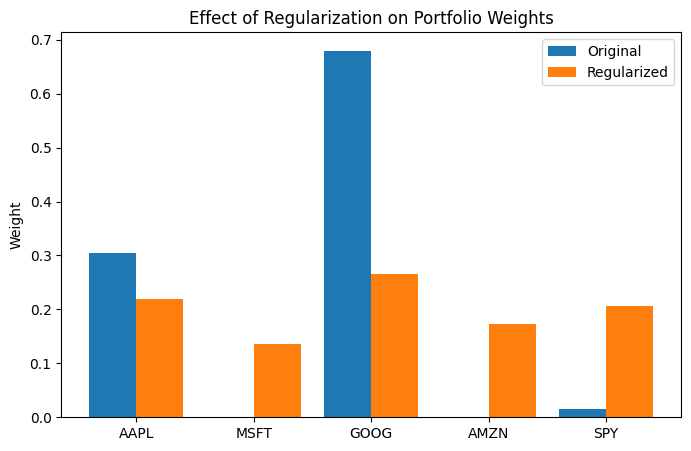

In [160]:
plt.figure(figsize=(8,5))
plt.bar(x - 0.2, exact_max_sharpe_weights, width=0.4, label="Original")
plt.bar(x + 0.2, reg_weights, width=0.4, label="Regularized")

plt.xticks(x, tickers)
plt.ylabel("Weight")
plt.title("Effect of Regularization on Portfolio Weights")
plt.legend()
plt.show()

### Effect of regularization on portfolio allocation

This figure compares the original maximum-Sharpe portfolio with the portfolio obtained using regularization.

Regularization introduces a penalty on large portfolio weights, discouraging extreme allocations and promoting diversification. In this implementation, a quadratic penalty is added to the objective function, which penalizes the squared magnitude of the weights.

Compared to the original portfolio, which is highly concentrated, the regularized portfolio is significantly more balanced. All assets receive a non-negligible allocation, and extreme positions are reduced. This reflects the fact that the optimization now trades off maximizing the Sharpe ratio with controlling the size of the weights.

This demonstrates that regularization is an effective way to stabilize portfolio optimization, reducing sensitivity to estimation error and producing more robust allocations.

### Combined both methods

In [161]:
combined_result = minimize(
    negative_sharpe_regularized,
    initial_weights,
    args=(shrunk_mean_returns, cov_matrix, lambda_reg),
    method='SLSQP',
    constraints=constraints
)

combined_weights = combined_result.x

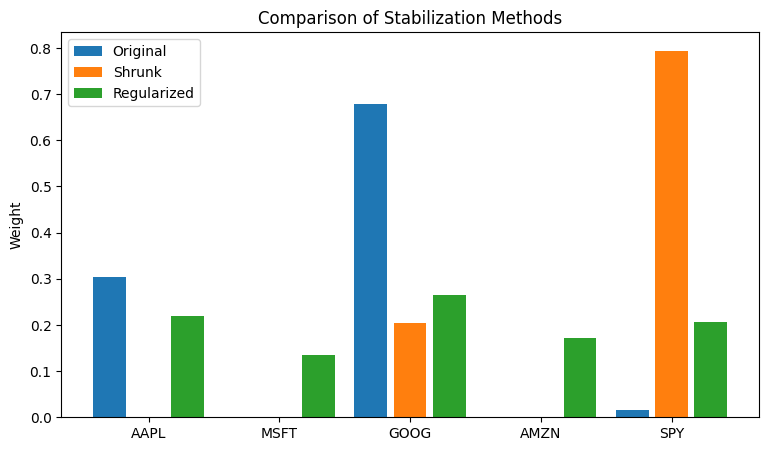

In [162]:
plt.figure(figsize=(9,5))

plt.bar(x - 0.3, exact_max_sharpe_weights, width=0.25, label="Original")
plt.bar(x, shrunk_weights, width=0.25, label="Shrunk")
plt.bar(x + 0.3, reg_weights, width=0.25, label="Regularized")

plt.xticks(x, tickers)
plt.ylabel("Weight")
plt.title("Comparison of Stabilization Methods")
plt.legend()
plt.show()

### Comparison of stabilization methods

This figure compares three portfolio allocations: the original maximum-Sharpe portfolio, the portfolio obtained with mean shrinkage, and the portfolio obtained with regularization.

The original portfolio is highly concentrated, assigning most of the weight to a small number of assets. The shrinkage approach reduces the dispersion of estimated returns, which leads to a reallocation of weights and a more balanced portfolio, although it may still exhibit some concentration.

The regularized portfolio, on the other hand, is the most evenly distributed. By explicitly penalizing large weights, regularization enforces diversification and prevents extreme allocations.

Overall, both methods improve stability compared to the original optimization, but they act in different ways: shrinkage modifies the inputs to reduce noise, while regularization modifies the optimization problem itself to control the complexity of the solution. In practice, combining both approaches often leads to the most robust results.